In [3]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import umap
from matplotlib.lines import Line2D
from typing import List, Optional, Literal

import matplotlib.pyplot as plt


In [4]:
##Opening the pickle file
with open("/nfs/users/nfs_d/dn10/lustre-127-tic/data/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[2, 5, 10, 16]/spatial_n_neighs_8/wandb/offline-run-20250911_111648-zonhkp1j/results/epoch=8-train_pearson_1hop_nbr=0.88/predict_adata.pkl", "rb") as f:
    adata = pickle.load(f)

In [5]:
print(type(adata))
adata.obs.head()

<class 'anndata._core.anndata.AnnData'>


,cell_types,niche_types,adata_batch_ids
0,F2: Universal,Interstitial stroma,2
1,KC3,Interstitial stroma,2
2,F2: Universal,Interstitial stroma,2
3,T_vascular,Perivascular depeer,2
4,VE/Pericyte,Perivascular depeer,2


In [6]:
print('obsm keys:', adata.obsm.keys())
for k in adata.obsm.keys():
    print(k, adata.obsm[k].shape)

obsm keys: KeysView(AxisArrays with keys: spatial, H_latent, H_quantized, H_adj)
spatial (44145, 2)
H_latent (44145, 200)
H_quantized (44145, 200)
H_adj (44145, 600)


In [7]:
adata.obs.columns

Index(['cell_types', 'niche_types', 'adata_batch_ids'], dtype='object')

In [8]:
print(adata.uns.keys())
for k in adata.uns.keys():
    print(k,type(adata.uns.keys()))

odict_keys(['X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'])
X <class 'odict_keys'>
X_nbr <class 'odict_keys'>
edge_index <class 'odict_keys'>
Indices <class 'odict_keys'>
X_hat <class 'odict_keys'>
X_hat_nbr <class 'odict_keys'>
Logits <class 'odict_keys'>
codebook_size <class 'odict_keys'>
separate <class 'odict_keys'>
num_heads <class 'odict_keys'>


In [9]:
indices = adata.uns['Indices']
print(type(indices))
print(indices[:5])
adata.obs['Indices'] = indices

<class 'torch.Tensor'>
tensor([2056, 3989, 1088, 4468, 1047])


In [10]:
coords = adata.obsm['spatial']
x = coords[:, 0]
y = coords[:, 1]
codes = adata.obs['Indices'].astype(int)

In [10]:
sample_batch_map = {
                    
                    'BK27_Day 14': 1,
                    'BK21_Lesional Baseline': 2,
                    'BK20_Lesional Baseline': 3,
                    'BK18_Non-lesional Baseline': 4,
                    'BK21_Day 3': 5,
                    'BK18_Week 12': 6,
                    'BK20_Day 14': 7,
                    'BK20_Non-lesional Baseline': 8,
                    'BK27_Non-lesional Baseline': 9,
                    'BK21_Day 14': 10,
                    'BK18_Lesional Baseline': 11,
                    'BK18_Day 3': 12,
                    'BK27_Day 3': 13,
                    'BK21_Non-lesional Baseline': 14,
                    'BK20_Week 12': 15,
                    'BK21_Week 12': 16,
                    'BK20_Day 3': 17,
                    'BK18_Day 14': 18,
                    'BK39_Lesional Baseline': 19,
                    'BK30_Non-lesional Baseline': 20,
                    'BK39_Non-lesional Baseline': 21,
                    'BK39_Week 12': 22,
                    'BK25_Day 3': 23,
                    'BK25_Day 14': 24,
                    'BK25_Non-lesional Baseline': 25,
                    'BK30_Day 3': 26,
                    'BK30_Day 14': 27,
                    'BK25_Lesional Baseline': 28,
                    'BK25_Week 12': 29,
                    'BK24_Lesional Baseline': 30,
                    'BK24_Day 14': 31,
                    'BK30_Lesional Baseline': 32,
                    'BK24_Non-lesional Baseline': 33,
                    'BK39_Day 14': 34,
                    'BK24_Day 3': 35,
                    'BK30_Week 12': 36,
                    'BK24_Week 12': 37,
                    'BK39_Day 3': 38
                    } 

Verifying xy coordinates colored by cell indices with the function

In [11]:
def plot_code_assignment_on_xy_coordinates(
        adata: adata,
        spatial_key: str = "spatial",
        label_key: str = "Indices",
        save_fname: Optional[str] = None,
        title: Optional[str] = "X-Y coordinates colored by Code Indices",
    ) -> None:
    """
    Plots the X-Y coordinates of the cells colored by the code indices.

    Parameters
    ----------
    adata : ad.AnnData
        The AnnData object containing the data to plot.
    spatial_key : str, optional
        The key in adata.obsm to use for the spatial coordinates.
    label_key : str, optional
        The key in adata.obs to use for the label.
    save_fname : str, optional
        The file name to save the plot to.
    title : str, optional
        The title of the plot.

    Returns
    -------
    None
    """
    # plot the X-Y coordinates of the cells colored by the code indices
    fig, ax = plt.subplots(1,1, figsize=(4,3))
    
    sns.scatterplot(
        x=adata.obsm[spatial_key][:,0],
        y=adata.obsm[spatial_key][:,1],
        hue=adata.obs[label_key],
        s=15
        
    )

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    fig.legend(
            handles, labels,
            title=label_key,
            loc='center left',
            bbox_to_anchor=(0.95, 0.5),
            borderaxespad=0.1,
            frameon=False,
        )

    if save_fname:
        plt.savefig(
            save_fname,
            dpi=300,
            bbox_inches='tight',
        )
    else:
        plt.show()    

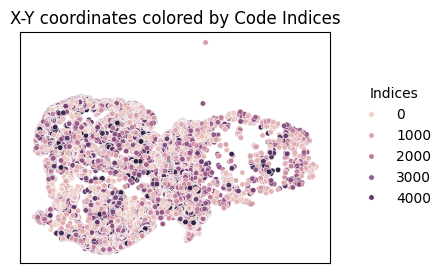

In [12]:
plot_code_assignment_on_xy_coordinates(
        adata = adata,
        spatial_key = "spatial",
        label_key = "Indices",
        title = "X-Y coordinates colored by Code Indices")

Updating the function to plot xy_coordinates_per_batch colored by cell indices

In [13]:
def plot_code_assignment_on_xy_coordinates_per_batch(
    adata,
    spatial_key="spatial",
    label_key="Indices",
    batch_key=None,
    save_fname=None,
    title="X-Y coordinates colored by Code Indices per Batch",
):
    if batch_key is not None:
        batches = adata.obs[batch_key].dropna().unique()
    else:
        batches = ["all"]

    fig, axes = plt.subplots(1, len(batches), figsize=(6 * len(batches), 5))
    if len(batches) == 1:
        axes = [axes]

    for ax, batch in zip(axes, batches):
        idx = adata.obs[batch_key] == batch
        sns.scatterplot(
            x=adata.obsm[spatial_key][idx, 0],
            y=adata.obsm[spatial_key][idx, 1],
            hue=adata.obs[label_key][idx],
            ax=ax,
            palette="Spectral",
            legend=False,
            s=10,
        )
        ax.set_title(f"{title} - Batch {batch}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    if save_fname:
        plt.savefig(save_fname, dpi=300, bbox_inches="tight")
    else:
        plt.show()

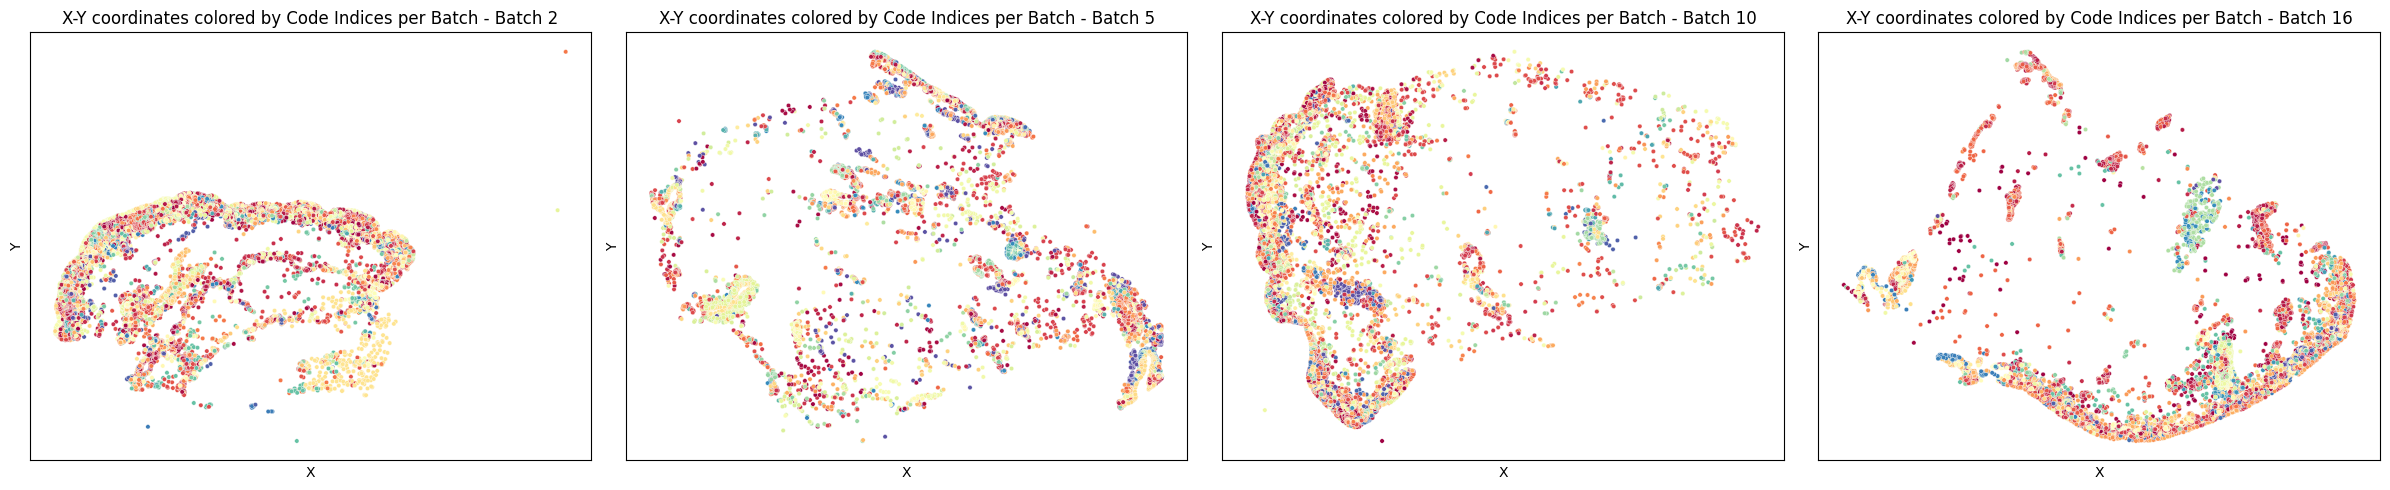

In [14]:
plot_code_assignment_on_xy_coordinates_per_batch(
    adata,
    spatial_key="spatial",
    label_key="Indices",
    batch_key="adata_batch_ids",
    title="X-Y coordinates colored by Code Indices per Batch",
)

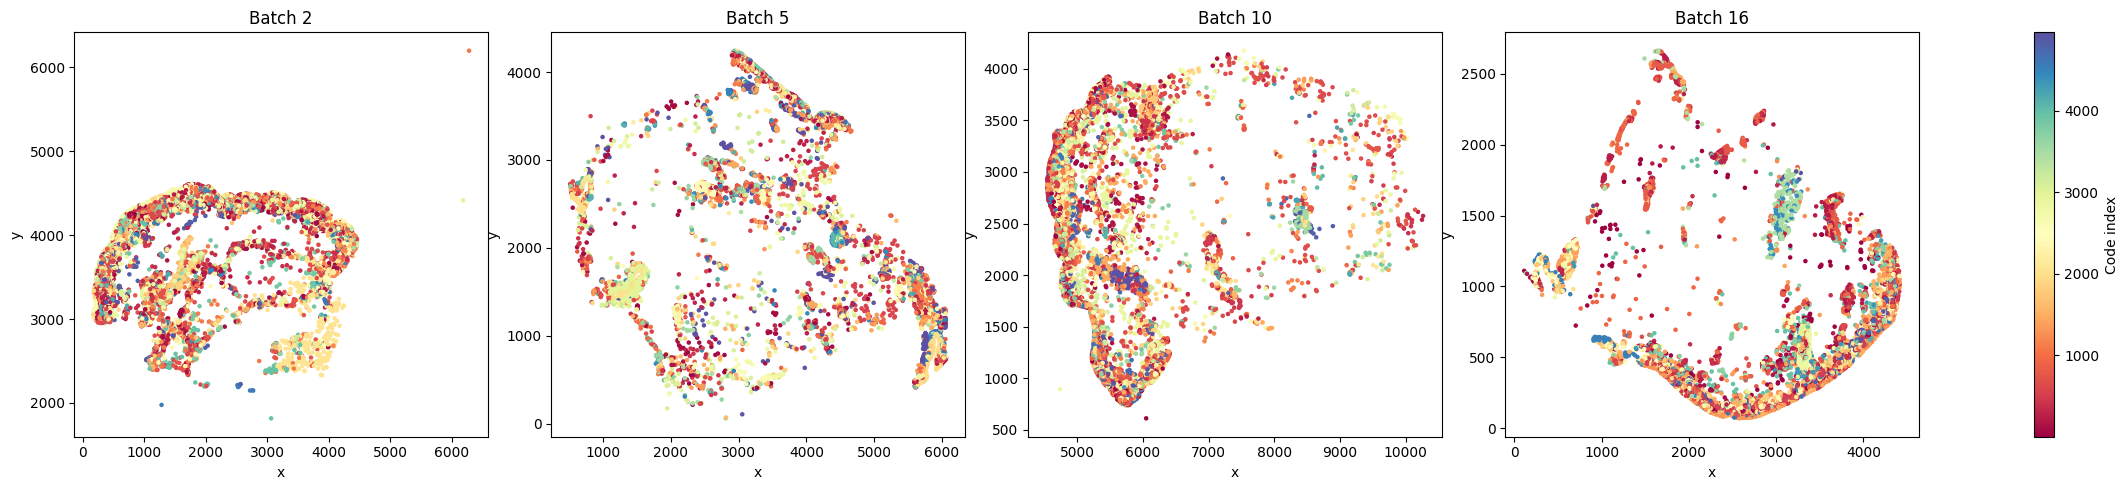

In [17]:
#Plotting tissues across batches(2,5,10,16)

batches = adata.obs['adata_batch_ids']
unique_batches = batches.dropna().unique()

fig, axes = plt.subplots(1, len(unique_batches), figsize=(6*len(unique_batches), 5))
if len(unique_batches) == 1:
    axes = [axes]

for ax, batch in zip(axes, unique_batches):
    idx = batches == batch
    sp = ax.scatter(
        x[idx],
        y[idx],
        c=codes[idx],              
        cmap='Spectral',           
        s=5
    )
    ax.set_title(f'Batch {batch}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
fig.colorbar(sp, ax=axes, label='Code index')
plt.show()

In [13]:
print(adata.obs['adata_batch_ids'].unique())


[ 2  5 10 16]


UMAP for H_quantized

In [37]:
def plot_umap_attribute_imputation(  
        adata: ad.AnnData,
        embedding_keys = ['H_quantized'],
        label_key: str = 'cell_types',
        save_fname: Optional[str] = None,
    ):
    """
    This function plots the UMAP embedding of original and imputed attributes colored by the label.
    
    Parameters
    ----------
    adata : ad.AnnData
        AnnData object with the data to be plotted.
    embedding_keys : List[Literal['X', 'X_hat', 'X_nbr', 'X_hat_nbr']]
        Keys in adata.obsm to use for the embedding.
    label_key : str
        Key in adata.obs to use for the label.
    save_fname : Optional[str]
        Path to save the plot. If None, the plot is not saved.
    
    Returns
    -------
    None
    
    Notes
    -----
    - We use sc.pl.embedding() instead of sc.pl.umap() because scanpy does not use the layer information correctly. umap() checks for basis='X' or basis='X_umap' to use the UMAP embedding without the layer information. So we bypass this and use embedding() directly by setting the basis to the embedding umap key.
    """
    for embedding_key in embedding_keys:
        if f"{embedding_key}_attr_umap" not in adata.obsm:
            raise KeyError(f"Run compute_umap_hquantized first to compute UMAP for '{key}'.")

    # making subplots depending on number of keys
    number_keys = len(embedding_keys)
    fig, axes = plt.subplots(1, number_keys, figsize=(6*number_keys, 6))
    axes = np.ravel(axes) if number_keys > 1 else [axes]

    handles, labels = None, None
    for i, (ax, embedding_key) in enumerate(zip(axes, embedding_keys)):
        sc.pl.embedding(
            adata=adata,
            basis=f'{embedding_key}_attr_umap',
            color=label_key,
            neighbors_key=f'{embedding_key}_attr_neighbors',
            show=False,
            ax=ax,
            legend_loc='right margin' if i == 0 else None,  
        )
        ax.set_title(embedding_key)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        ax.set_yticks([])        

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            ncol = max(1, int(np.ceil(len(labels)/25)))
            ax.get_legend().remove()  # remove it from the first plot and draw it globally
        
    # Add single global legend
    fig.subplots_adjust(right=0.82)  # shrink main plot area to make space
    fig.legend(
        handles, labels,
        title=label_key,
        loc='center left',
        bbox_to_anchor=(0.85, 0.5),
        ncol=ncol,
        borderaxespad=0.1,
        frameon=False,
    )

    if save_fname:
        plt.savefig(
            fname=save_fname,
            dpi=300,
            bbox_inches='tight',
        )
    else:
        plt.show()

In [33]:
def compute_umap(
        adata: ad.AnnData,
        embedding_keys: List[Literal['H_quantized']] = ['H_quantized'],
    ) -> ad.AnnData:
    """
    This function computes the nearest neighbor distance matrix and neighborhood graph,
    and embeds the neighborhood into 2D using UMAP.
    
    Parameters
    ----------
    adata : ad.AnnData
        AnnData object with the data to be processed.
    embedding_keys : List[Literal['X', 'X_hat', 'X_nbr', 'X_hat_nbr']]
        Key(s) in adata.obsm to compute UMAP embeddings of.
    
    Returns
    -------
    adata : ad.AnnData
        AnnData object with the UMAP embedding(s) added to adata.obsm.
        
    Notes
    -----
    - The X and X_hat are already keys in the adata.uns containing the original and reconstructed gene counts as tensors. 
    - sc.pp.neighbors() adds the neighbors to the adata.uns[key_added] and the distances are stored in adata.obsp[key_added+'_distances'] and connectivities in adata.obsp[key_added+'_connectivities'].
    - This would overwrite the adata.uns['X'] and adata.uns['X_hat'] keys. Therefore, we set the key_added to f'{embedding_key}_attr_neighbors'.
    - sc.tl.umap() adds the embedding to the adata.obsm[key_added] and the parameters in adata.uns[key_added].
    """
    for embedding_key in embedding_keys:
        print(f"Computing UMAP for {embedding_key}..")
        
        # convert the tensor to numpy array
        if embedding_key not in adata.obsm:
            adata.obsm[embedding_key] = adata.uns[embedding_key].cpu().numpy()

        # compute nearest neighbor distance matrix and neighborhood graph
        print(f"Computing nearest neighbor distance matrix and neighborhood graph for {embedding_key}..")
        sc.pp.neighbors(
            adata=adata,
            n_neighbors=15, # default is 15
            knn=True, # default is True
            random_state=42,
            use_rep=embedding_key,
            key_added=f'{embedding_key}_attr_neighbors',
        )

        # embed the neighborhood into 2D using UMAP
        print(f"Embedding the neighborhood into 2D using UMAP for {embedding_key}..")
        sc.tl.umap(
            adata=adata,
            min_dist=0.5, # default is 0.5
            spread=1.0, # default is 1.0
            alpha=1.0, # default is 1.0
            gamma=1.0, # default is 1.0
            negative_sample_rate=5,
            init_pos='random',# default is 5
            random_state=42,
            neighbors_key=f'{embedding_key}_attr_neighbors',
            key_added=f'{embedding_key}_attr_umap',
        )

    return adata

In [34]:
#Compute the UMAP coordinates
adata = compute_umap(adata, embedding_keys=['H_quantized'])

Computing UMAP for H_quantized..
Computing nearest neighbor distance matrix and neighborhood graph for H_quantized..
Embedding the neighborhood into 2D using UMAP for H_quantized..


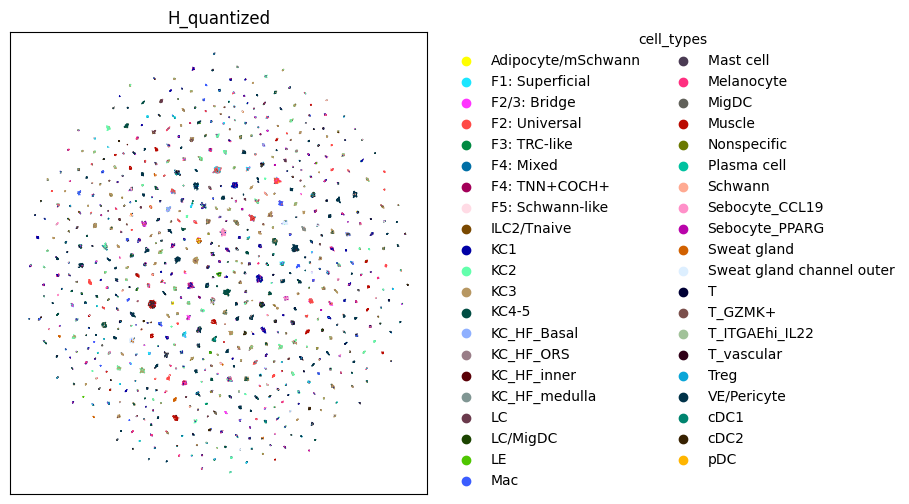

In [38]:
plot_umap_attribute_imputation(
    adata,
    embedding_keys=['H_quantized'], 
    label_key='cell_types'            # or 'niche_types'
)

In [84]:
print('neighbors present?','H_quantized_attr_neighbors' in adata.uns)

neighbors present? True


Checking H_latent UMAP to determine if the problem is with the model’s feature learning or with the quantization step; since UMAP for H_quantized looked wrong.

In [29]:
#Compute Neighbors Using H_latent
sc.pp.neighbors(adata, use_rep = 'H_latent', knn= True, n_neighbors =15, key_added= 'H_latent_attr_neighbors')


In [30]:
#Run UMAP Embedding
sc.tl.umap(adata, min_dist=0.5, spread=1.0, alpha=1.0, init_pos='random',gamma=1.0, negative_sample_rate=5,random_state = 42, neighbors_key='H_latent_attr_neighbors' )


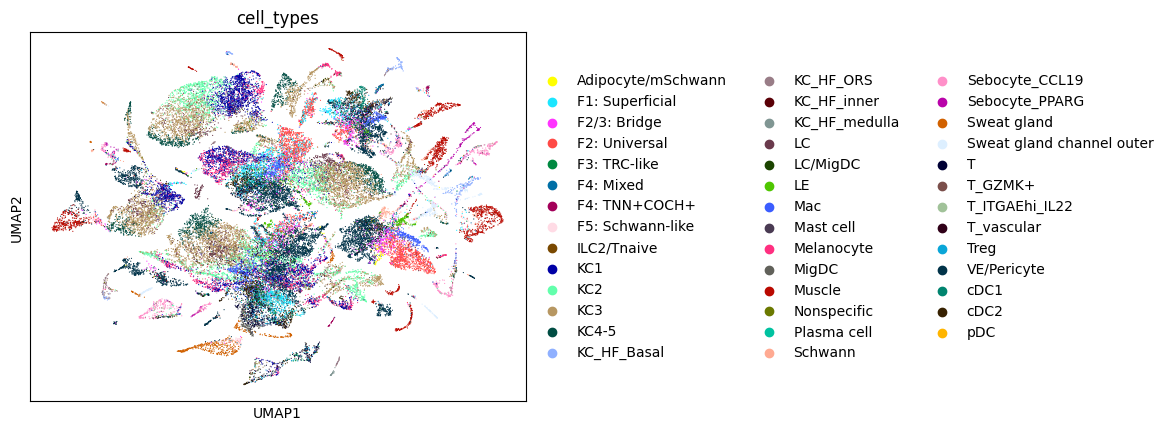

In [31]:
#Plot the UMAP
sc.pl.umap(adata, color ='cell_types', neighbors_key='H_latent_attr_neighbors', legend_loc='right margin',show=True)